# Metallicity-dependent MLR test plot

Use the cells below to enter your fitted parameters and visualize the MLR vs. the isochrone at multiple metallicities.


In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add the package to Python path
def _find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "bayesian-binary-masses" / "src").exists():
            return path
    return start

repo_root = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(repo_root / "bayesian-binary-masses" / "src"))

from binary_masses.differencepoly_feh import (
    DifferencePolyFehMassAbsgModel,
    IsochroneMassSurfaceModel,
)

iso_data_dir = repo_root / "bayesian-binary-masses" / "data" / "interpolated_mass_data"
iso_surface = IsochroneMassSurfaceModel.from_interpolated_mass_data(
    str(iso_data_dir),
    mass_min=0.05,
)


In [6]:
# -------------------------
# User inputs
# Model: log10 m_dyn(M_G, MH) = log10 m_iso(M_G, MH) + Σ_i (a_i + b_i * z(MH)) x(M_G)^i
# -------------------------
order = 2
absg_min, absg_max = 3.5, 14.0
mass_min, mass_max = 0.05, 2.0
feh_min, feh_max = -1.0, 0.6

# Choose the metallicity values to compare
feh_values = [-1.0, -0.5, 0.0, 0.3, 0.6]

# Option A: single set of coefficients (no uncertainty band)
# a_coeffs and b_coeffs should each have length order+1
a_coeffs = [0.02, 0.06, 0.01]
b_coeffs = [-0.08, 0, 0]
params = np.array(a_coeffs + b_coeffs, dtype=float)

# Option B: posterior samples (uncertainty band)
# params_samples shape: (n_samples, 2*(order+1))
# params_samples = np.loadtxt("path/to/mcmc_samples.txt")
params_samples = None


In [7]:
# -------------------------
# Load data + posterior samples for per-point likelihoods
# -------------------------
from astropy.table import Table

data_path = repo_root / 'bayesian-binary-masses' / 'data' / 'jd_single_1kpc_filtered.fits'
data = Table.read(data_path)

# Compute u and u_sigma if not already present
if 'u' not in data.colnames:
    v = 4.74 * np.sqrt((data['pmra2'] - data['pmra1'])**2 + (data['pmdec2'] - data['pmdec1'])**2) / data['parallax1']
    data['u'] = v * np.sqrt(data['sep_AU'])
if 'u_sigma' not in data.colnames and 'dpm_over_error' in data.colnames:
    data['u_sigma'] = data['u'] / data['dpm_over_error']

# Choose which Fe/H column to use
feh_column = 'feh' if 'feh' in data.colnames else 'feh_jcaps_1'

# Path to your posterior samples
samples_path = repo_root / 'bayesian-binary-masses' / 'results' / 'feh_continuous_results' / 'mcmc_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].txt'
params_samples = np.loadtxt(samples_path)


In [8]:
# -------------------------
# Speed controls + JAX accelerated likelihood (chunked)
# -------------------------
import numpy as np

# Randomly subsample posterior draws for speed
max_draws = 500  # adjust (e.g., 200-1000)
rng = np.random.default_rng(42)
if params_samples.shape[0] > max_draws:
    draw_idx = rng.choice(params_samples.shape[0], size=max_draws, replace=False)
    params_samples = params_samples[draw_idx]

def compute_log_pred_p_out_jax_chunked_chunked(
    *,
    params_samples,
    order,
    absg_min,
    absg_max,
    mass_min,
    feh_min,
    feh_max,
    iso_surface,
    data,
    feh_column,
    uncertainty_model='rice',
    int_umax=80.0,
    int_du=0.05,
    f_outlier_init=0.1,
    outlier_u0_init=30.0,
    outlier_sigma_init=15.0,
    p_epsilon=1e-10,
    sample_chunk=64,
    data_chunk=2048,
):
    # JAX imports here to avoid forcing dependency unless needed
    import jax
    import jax.numpy as jnp
    from jax.scipy.special import i0e as jax_i0e
    from jax.scipy.special import erf as jax_erf

    model = DifferencePolyFehMassAbsgModel(
        order=order,
        absg_min=absg_min,
        absg_max=absg_max,
        mass_min=mass_min,
        pivot=(absg_min + absg_max) / 2.0,
        deriv_penalty_strength=0.0,
        isochrone_surface_model=iso_surface,
        feh_min=feh_min,
        feh_max=feh_max,
    )

    u = np.asarray(data['u'], float)
    u_sigma = np.asarray(data['u_sigma'], float) if 'u_sigma' in data.colnames else None
    absg1 = np.asarray(data['absg1'], float)
    absg2 = np.asarray(data['absg2'], float)
    feh = np.asarray(data[feh_column], float)

    n_base = order + 1
    n_coeff = 2 * n_base
    samples = np.atleast_2d(params_samples)
    if samples.shape[1] == n_coeff + 3:
        coeff_samples = samples[:, :n_coeff]
        f_outlier = samples[:, n_coeff]
        outlier_u0 = samples[:, n_coeff + 1]
        outlier_sigma = samples[:, n_coeff + 2]
    elif samples.shape[1] == n_coeff:
        coeff_samples = samples
        f_outlier = np.full(samples.shape[0], f_outlier_init, dtype=float)
        outlier_u0 = np.full(samples.shape[0], outlier_u0_init, dtype=float)
        outlier_sigma = np.full(samples.shape[0], outlier_sigma_init, dtype=float)
    else:
        raise ValueError(f'Unexpected sample width: {samples.shape[1]} (expected {n_coeff} or {n_coeff + 3})')

    n_samples = coeff_samples.shape[0]

    if u_sigma is None:
        norm_factor = np.ones_like(u)
    elif uncertainty_model == 'gaussian':
        norm_factor = 1.0 - 0.5 * (1.0 + np.erf((-u) / (np.maximum(u_sigma, 1e-10) * np.sqrt(2.0))))
    else:
        norm_factor = np.ones_like(u)

    int_ulist = jnp.arange(0.0, float(int_umax), float(int_du))
    func_ulist = 4.95e-3 * int_ulist * jnp.exp(-1.0 * (2.24e-3 * int_ulist**2 + jnp.exp((int_ulist - 36.09) / 3.85)))

    def rice_pdf(u_obs, u_true, sigma):
        sigma = jnp.maximum(sigma, 1e-10)
        sigma_sq = sigma**2
        bessel_arg = u_obs * u_true / sigma_sq
        log_prefactor = jnp.log(u_obs + 1e-100) - jnp.log(sigma_sq)
        log_exp_term = -(u_obs**2 + u_true**2) / (2 * sigma_sq)
        log_bessel = jnp.log(jax_i0e(bessel_arg) + 1e-100) + jnp.abs(bessel_arg)
        return jnp.maximum(jnp.exp(log_prefactor + log_exp_term + log_bessel), 1e-100)

    def gaussian_pdf(x, mu, sigma):
        sigma = jnp.maximum(sigma, 1e-10)
        return (1.0 / (sigma * jnp.sqrt(2 * jnp.pi))) * jnp.exp(-0.5 * ((x - mu) / sigma) ** 2)

    def likelihood_for_sample(theta, f_out, u0, sig, u_c, u_sigma_c, absg1_c, absg2_c, feh_c, norm_c):
        m1 = model.mass_from_absg_feh_jax(absg1_c, feh_c, theta)
        m2 = model.mass_from_absg_feh_jax(absg2_c, feh_c, theta)
        sqrt_mtot = jnp.sqrt(jnp.maximum(m1 + m2, 1e-12))
        tilde_u = u_c / sqrt_mtot

        if u_sigma_c is None:
            good = (1.0 / sqrt_mtot) * (4.95e-3 * tilde_u * jnp.exp(-1.0 * (2.24e-3 * tilde_u**2 + jnp.exp((tilde_u - 36.09) / 3.85))))
        else:
            u_obs_grid = (u_c / sqrt_mtot)[:, None]
            sigma_grid = (u_sigma_c / sqrt_mtot)[:, None]
            integration_grid = int_ulist[None, :]
            if uncertainty_model == 'rice':
                unc = rice_pdf(u_obs_grid, integration_grid, sigma_grid)
            else:
                unc = gaussian_pdf(u_obs_grid, integration_grid, sigma_grid)
            integrand = (1.0 / sqrt_mtot[:, None]) * func_ulist[None, :] * unc * float(int_du)
            norm = jnp.maximum(norm_c, 1e-10)
            good = jnp.sum(integrand, axis=1) / norm + p_epsilon / (int_umax / int_du)

        outlier_norm = 1.0 - 0.5 * (1.0 + jax_erf(-u0 / jnp.maximum(sig, 1e-10) / jnp.sqrt(2.0)))
        outlier = gaussian_pdf(tilde_u, u0, sig) / jnp.maximum(outlier_norm, 1e-10)

        total = (1.0 - f_out) * good + f_out * outlier + p_epsilon
        total = jnp.clip(total, 1e-100, 1e10)
        p_out = (f_out * outlier) / total
        return total, p_out

    sum_probs = np.zeros(u.shape[0], dtype=float)
    sum_out = np.zeros(u.shape[0], dtype=float)

    for d0 in range(0, u.shape[0], data_chunk):
        d1 = min(d0 + data_chunk, u.shape[0])
        u_c = jnp.asarray(u[d0:d1])
        u_sigma_c = None if u_sigma is None else jnp.asarray(u_sigma[d0:d1])
        absg1_c = jnp.asarray(absg1[d0:d1])
        absg2_c = jnp.asarray(absg2[d0:d1])
        feh_c = jnp.asarray(feh[d0:d1])
        norm_c = jnp.asarray(norm_factor[d0:d1])

        sum_probs_c = np.zeros(d1 - d0, dtype=float)
        sum_out_c = np.zeros(d1 - d0, dtype=float)

        for s0 in range(0, n_samples, sample_chunk):
            s1 = min(s0 + sample_chunk, n_samples)
            coeff_c = jnp.asarray(coeff_samples[s0:s1])
            f_out_c = jnp.asarray(f_outlier[s0:s1])
            u0_c = jnp.asarray(outlier_u0[s0:s1])
            sig_c = jnp.asarray(outlier_sigma[s0:s1])

            total_probs, outlier_probs = jax.vmap(likelihood_for_sample, in_axes=(0, 0, 0, 0, None, None, None, None, None, None))(
                coeff_c, f_out_c, u0_c, sig_c, u_c, u_sigma_c, absg1_c, absg2_c, feh_c, norm_c
            )

            sum_probs_c += np.asarray(jnp.sum(total_probs, axis=0))
            sum_out_c += np.asarray(jnp.sum(outlier_probs, axis=0))

        sum_probs[d0:d1] = sum_probs_c
        sum_out[d0:d1] = sum_out_c

    log_pred = np.log(sum_probs / n_samples)
    p_out = sum_out / n_samples

    return log_pred, p_out


In [9]:
from scipy.special import i0e, erf
from scipy.stats import norm

def _func_pu_8(tilde_u, A=4.95e-3, B=2.24e-3, C=3.85, u0=36.09):
    return A * tilde_u * np.exp(-1 * (B * tilde_u**2 + np.exp((tilde_u - u0) / C)))

def _rice_pdf(u_obs, u_true, sigma):
    sigma = np.maximum(sigma, 1e-10)
    sigma_sq = sigma**2
    bessel_arg = u_obs * u_true / sigma_sq
    log_prefactor = np.log(u_obs + 1e-100) - np.log(sigma_sq)
    log_exp_term = -(u_obs**2 + u_true**2) / (2 * sigma_sq)
    log_bessel = np.log(i0e(bessel_arg) + 1e-100) + np.abs(bessel_arg)
    return np.maximum(np.exp(log_prefactor + log_exp_term + log_bessel), 1e-100)

def _gaussian_pdf(x, mu, sigma):
    sigma = np.maximum(sigma, 1e-10)
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def compute_log_pred_p_out(
    *,
    params_samples,
    order,
    absg_min,
    absg_max,
    mass_min,
    feh_min,
    feh_max,
    iso_surface,
    data,
    feh_column,
    uncertainty_model='rice',
    int_umax=80.0,
    int_du=0.02,
    f_outlier_init=0.1,
    outlier_u0_init=30.0,
    outlier_sigma_init=15.0,
    p_epsilon=1e-10,
):
    model = DifferencePolyFehMassAbsgModel(
        order=order,
        absg_min=absg_min,
        absg_max=absg_max,
        mass_min=mass_min,
        pivot=(absg_min + absg_max) / 2.0,
        deriv_penalty_strength=0.0,
        feh_monotone_strength=0.0,
        isochrone_surface_model=iso_surface,
        feh_min=feh_min,
        feh_max=feh_max,
    )

    u = np.asarray(data['u'], float)
    u_sigma = np.asarray(data['u_sigma'], float) if 'u_sigma' in data.colnames else None
    absg1 = np.asarray(data['absg1'], float)
    absg2 = np.asarray(data['absg2'], float)
    feh = np.asarray(data[feh_column], float)

    n_base = order + 1
    n_coeff = 2 * n_base
    samples = np.atleast_2d(params_samples)
    if samples.shape[1] == n_coeff + 3:
        coeff_samples = samples[:, :n_coeff]
        f_outlier = samples[:, n_coeff]
        outlier_u0 = samples[:, n_coeff + 1]
        outlier_sigma = samples[:, n_coeff + 2]
    elif samples.shape[1] == n_coeff:
        coeff_samples = samples
        f_outlier = np.full(samples.shape[0], f_outlier_init, dtype=float)
        outlier_u0 = np.full(samples.shape[0], outlier_u0_init, dtype=float)
        outlier_sigma = np.full(samples.shape[0], outlier_sigma_init, dtype=float)
    else:
        raise ValueError(f'Unexpected sample width: {samples.shape[1]} (expected {n_coeff} or {n_coeff + 3})')

    if u_sigma is None:
        norm_factor = np.ones_like(u)
    elif uncertainty_model == 'gaussian':
        norm_factor = 1.0 - norm.cdf(0.0, loc=u, scale=u_sigma)
    else:
        norm_factor = np.ones_like(u)

    int_ulist = np.arange(0.0, float(int_umax), float(int_du))

    probs = []
    outlier_probs = []

    for s, theta in enumerate(coeff_samples):
        m1 = model.mass_from_absg_feh(absg1, feh, theta)
        m2 = model.mass_from_absg_feh(absg2, feh, theta)
        sqrt_mtot = np.sqrt(np.maximum(m1 + m2, 1e-12))
        tilde_u = u / sqrt_mtot

        if u_sigma is None:
            good = (1.0 / sqrt_mtot) * _func_pu_8(tilde_u)
        else:
            u_obs_grid = (u / sqrt_mtot)[:, None]
            sigma_grid = (u_sigma / sqrt_mtot)[:, None]
            integration_grid = int_ulist[None, :]

            if uncertainty_model == 'rice':
                unc = _rice_pdf(u_obs_grid, integration_grid, sigma_grid)
            else:
                unc = _gaussian_pdf(u_obs_grid, integration_grid, sigma_grid)

            integrand = (1.0 / sqrt_mtot[:, None]) * _func_pu_8(int_ulist)[None, :] * unc * float(int_du)
            norm = np.maximum(norm_factor, 1e-10)
            good = np.sum(integrand, axis=1) / norm + p_epsilon / (int_umax / int_du)

        outlier_norm = 1.0 - 0.5 * (1.0 + erf(-outlier_u0[s] / outlier_sigma[s] / np.sqrt(2.0)))
        outlier = _gaussian_pdf(tilde_u, outlier_u0[s], outlier_sigma[s]) / np.maximum(outlier_norm, 1e-10)

        total = (1.0 - f_outlier[s]) * good + f_outlier[s] * outlier + p_epsilon
        total = np.clip(total, 1e-100, 1e10)

        probs.append(total)
        outlier_probs.append((f_outlier[s] * outlier) / total)

    probs = np.asarray(probs)
    outlier_probs = np.asarray(outlier_probs)

    log_pred = np.log(np.mean(probs, axis=0))
    p_out = np.mean(outlier_probs, axis=0)

    return log_pred, p_out

log_pred, p_out = compute_log_pred_p_out_jax(
    params_samples=params_samples,
    order=order,
    absg_min=absg_min,
    absg_max=absg_max,
    mass_min=mass_min,
    feh_min=feh_min,
    feh_max=feh_max,
    iso_surface=iso_surface,
    data=data,
    feh_column=feh_column,
    uncertainty_model='rice',
)

data['log_pred'] = log_pred
data['p_out'] = p_out

top_idx = np.argsort(p_out)[-10:][::-1]
data[top_idx][['log_pred', 'p_out', feh_column, 'absg1', 'absg2']].pprint(max_width=120)


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[6]
This BatchTracer with object id 6075476080 was created on line:
  /var/folders/07/jrvmv73d07v7_jgbkqr220km0000gn/T/ipykernel_72933/3471705033.py:135:33 (compute_log_pred_p_out_jax)
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [ ]:
def plot_mlr_multi_feh(
    *,
    params,
    params_samples,
    feh_values,
    absg_min,
    absg_max,
    mass_min,
    mass_max,
    feh_min,
    feh_max,
    iso_surface,
    order,
):
    model = DifferencePolyFehMassAbsgModel(
        order=order,
        absg_min=absg_min,
        absg_max=absg_max,
        mass_min=mass_min,
        pivot=(absg_min + absg_max) / 2.0,
        deriv_penalty_strength=0.0,
        feh_monotone_strength=0.0,
        isochrone_surface_model=iso_surface,
        feh_min=feh_min,
        feh_max=feh_max,
    )

    absg_range = np.linspace(absg_min, absg_max, 600)
    feh_values = np.asarray(feh_values, dtype=float)
    feh_values = np.sort(feh_values[np.isfinite(feh_values)])

    cmap = plt.cm.viridis
    norm = plt.Normalize(feh_values.min(), feh_values.max())

    fig, ax = plt.subplots(figsize=(10, 6))

    for feh in feh_values:
        color = cmap(norm(feh))
        if params_samples is not None:
            masses = model.mass_from_absg_feh(absg_range, feh, params_samples)
            lower, median, upper = np.percentile(masses, [16, 50, 84], axis=0)
            ax.fill_between(absg_range, lower, upper, color=color, alpha=0.18)
            ax.plot(absg_range, median, color=color, linewidth=2)
        else:
            masses = model.mass_from_absg_feh(absg_range, feh, params)
            ax.plot(absg_range, masses, color=color, linewidth=2)

        iso_mass = iso_surface.mass_from_absg_mh(absg_range, feh)
        ax.plot(absg_range, iso_mass, color=color, linewidth=1.5, linestyle="--", alpha=0.8)

    ax.set_xlabel("$M_{\\mathrm{G}}$ [mag]")
    ax.set_ylabel("Mass [$M_{\\odot}$]")
    ax.set_xlim(absg_min, absg_max)
    ax.set_ylim(mass_min * 0.8, mass_max * 1.2)
    ax.set_yscale("log")
    ax.invert_xaxis()

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("[Fe/H]", rotation=270, labelpad=12)

    ax.legend(["Fit", "Isochrone"], loc="best")
    plt.tight_layout()
    plt.show()


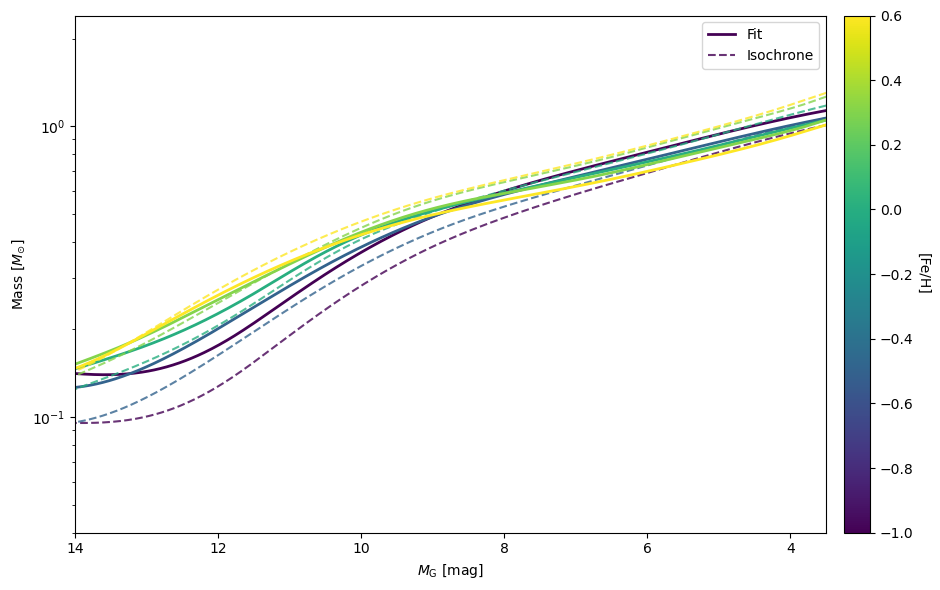

In [18]:
# Run plot
plot_mlr_multi_feh(
    params=params,
    params_samples=params_samples,
    feh_values=feh_values,
    absg_min=absg_min,
    absg_max=absg_max,
    mass_min=mass_min,
    mass_max=mass_max,
    feh_min=feh_min,
    feh_max=feh_max,
    iso_surface=iso_surface,
    order=order,
)


In [2]:
# read .npz file
import numpy as np

data = np.load('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/results/data_diffpoly_feh_pred_kappa0p5/predictive_metrics_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].npz')


In [5]:
data['p_out']

array([0.12123092, 0.13023634, 0.13711419, ..., 0.15193285, 0.07293887,
       0.16951327], shape=(12794,))

In [8]:
# read /Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/data/jd_single_1kpc_filtered.fits

import numpy as np
from astropy.table import Table

table = Table.read('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/data/jd_single_1kpc_filtered.fits')
table['pred_p_out'] = data['p_out']

# save
table.write('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/data/jd_single_1kpc_filtered.fits', overwrite=True)